# Fine-tuning ModernBERT on GoEmotions with LoRA Adapters
**Task:** Multi-label emotion classification (28 classes)  
**Model:** `answerdotai/ModernBERT-base`  
**Method:** LoRA Adapter fine-tuning (`LoRAConfig`)

In [1]:
# Install / upgrade all required packages
!pip install -q transformers datasets accelerate kagglehub scikit-learn seaborn adapters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.5 MB/s eta 0:00:00


In [ ]:
# Core imports
import torch
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, hamming_loss
from pathlib import Path
from typing import Union

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
import kagglehub

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# ── All hyperparameters in one place ─────────────────────────────────────────────
MODEL_NAME  = "answerdotai/ModernBERT-base"
MAX_LENGTH  = 128       # GoEmotions comments are short, 128 is sufficient
BATCH_SIZE  = 32        # reduce to 16 if you get OOM errors
EPOCHS      = 10        # Increased for adapter fine-tuning
LR          = 2e-5
THRESHOLD   = 0.5       # sigmoid cutoff for predicting a label as active
OUTPUT_DIR  = "./modernbert-goemotions-lora"
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
# ── Clone repo and load dataset from CSV files ────────────────────────────────
import subprocess
import os

# Clone the repo if not already present (for Colab)
repo_path = "/content/NLP-Research"
if not os.path.exists(repo_path):
    print("Cloning repository...")
    subprocess.run(["git", "clone", "https://github.com/vanessa-laii/NLP-Research.git", repo_path], 
                   capture_output=True)
    print(f"Repository cloned to {repo_path}")
else:
    print(f"Repository already exists at {repo_path}")

# Look for dataset folder
dataset_path = os.path.join(repo_path, "dataset")
if not os.path.exists(dataset_path):
    dataset_path = "dataset"  # fallback to local

print(f"Dataset path: {dataset_path}")
print("Files in dataset/:", os.listdir(dataset_path))

# Load CSV files
train_df = pd.read_csv(os.path.join(dataset_path, "train.csv"))
val_df = pd.read_csv(os.path.join(dataset_path, "validation.csv"))
test_df = pd.read_csv(os.path.join(dataset_path, "test.csv"))

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print("\nDataFrame columns:")
print(train_df.columns.tolist())
train_df.head(3)

100%|██████████| 17.6M/17.6M [00:00<00:00, 72.1MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/debarshichanda/goemotions/versions/6
Files in data/: ['test.tsv', 'emotions.txt', 'dev.tsv', 'sentiment_mapping.json', 'sentiment_dict.json', 'full_dataset', 'train.tsv', 'ekman_labels.csv', 'ekman_mapping.json']
Train: 43,410  Val: 5,426  Test: 5,427


,text,labels,comment_id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj


In [ ]:
# ── Extract emotion class names and prepare multi-hot labels ──────────────────
# The emotion columns are all columns after 'created_utc'
exclude_cols = ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear']
emotion_labels = [col for col in train_df.columns if col not in exclude_cols]

NUM_LABELS = len(emotion_labels)
print(f"{NUM_LABELS} emotion classes: {emotion_labels}")

# Function to extract multi-hot labels from DataFrame
def get_labels_matrix(df, emotion_cols):
    return df[emotion_cols].values.astype(np.float32)

train_labels = get_labels_matrix(train_df, emotion_labels)
val_labels = get_labels_matrix(val_df, emotion_labels)
test_labels = get_labels_matrix(test_df, emotion_labels)

print(f"Label matrix shape (train): {train_labels.shape}")

28 classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


/tmp/ipykernel_4019/1642866104.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.index, y=freq.values, palette="viridis")


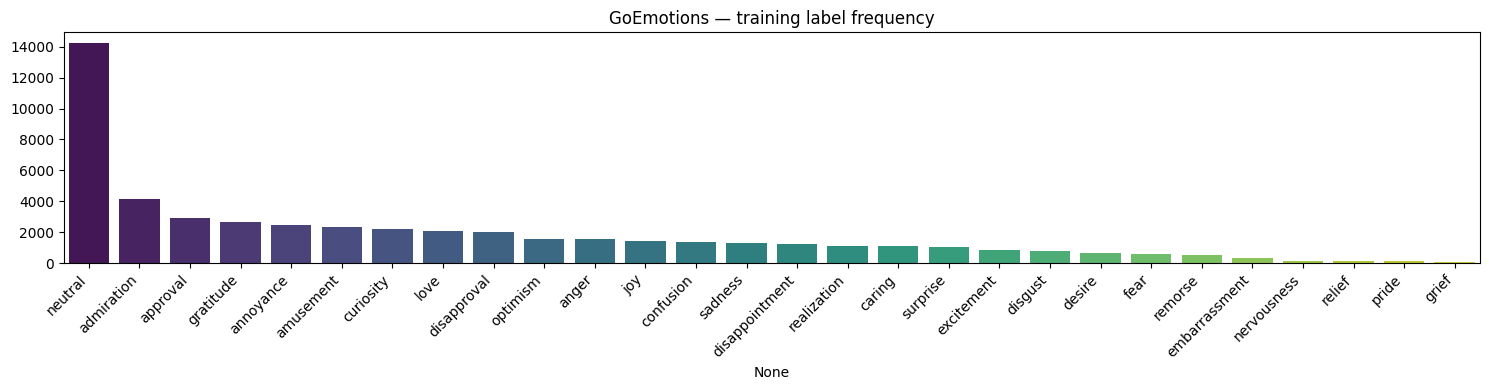

Avg labels per sample: 1.18


In [ ]:
# ── Quick EDA — label frequency + average labels per sample ──────────────────
counts = train_df[emotion_labels].sum().values.astype(int)
freq = pd.Series(counts, index=emotion_labels).sort_values(ascending=False)

plt.figure(figsize=(15, 4))
sns.barplot(x=freq.index, y=freq.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("GoEmotions — training label frequency")
plt.tight_layout()
plt.show()

avg = train_df[emotion_labels].sum(axis=1).mean()
print(f"Avg labels per sample: {avg:.2f}")

In [ ]:
# ── Label matrices already extracted correctly from CSV emotion columns ───────
# (no need to convert — CSV already has multi-hot 0/1 encoding)
print("Label matrix shape (train):", train_labels.shape)
print("Label matrix shape (val):", val_labels.shape)
print("Label matrix shape (test):", test_labels.shape)

Label matrix shape (train): (43410, 28)


In [9]:
# ── Tokenise all splits — padding is handled dynamically by the data collator ─
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LENGTH, padding=False)

train_enc = tokenize(train_df["text"])
val_enc   = tokenize(val_df["text"])
test_enc  = tokenize(test_df["text"])
print("Tokenisation complete.")

Loading tokenizer: answerdotai/ModernBERT-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenisation complete.


In [10]:
# ── PyTorch Dataset wrapper ────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = EmotionDataset(train_enc, train_labels)
val_dataset   = EmotionDataset(val_enc,   val_labels)
test_dataset  = EmotionDataset(test_enc,  test_labels)
print(f"Dataset sizes — train: {len(train_dataset):,}, val: {len(val_dataset):,}, test: {len(test_dataset):,}")

Dataset sizes — train: 43,410, val: 5,426, test: 5,427


In [11]:
# ── Load ModernBERT with a 28-class head + LoRA Adapter ──────────────────────
import adapters
from adapters import LoRAConfig

print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
)

# Initialise adapter support on the loaded model
adapters.init(model)

# Add LoRA adapter
config = LoRAConfig(r=8, alpha=16)
model.add_adapter("lora_adapter", config=config)

# Freeze backbone; train only the adapter weights
model.train_adapter("lora_adapter")

# Also unfreeze the classification head (randomly initialised, needs training)
for name, param in model.named_parameters():
    if "classifier" in name or "pooler" in name:
        param.requires_grad = True

model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total params: {total:.1f}M  |  Trainable: {trainable:.1f}M ({trainable/total*100:.1f}%)")

Loading model: answerdotai/ModernBERT-base


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 150.2M  |  Trainable: 1.2M (0.8%)


In [ ]:
# ── Plot loss curves helper function ──────────────────────────────────────────
def plot_loss_curves(
    history: dict = None,
    train_losses: list = None,
    val_losses: list = None,
    train_key: str = "train_loss",
    val_key: str = "val_loss",
    title: str = "Training & Validation Loss",
    save_path: Union[str, Path] = None,
    figsize: tuple = (9, 5),
    show: bool = True,
) -> plt.Figure:
    
    if train_losses is None and history is not None:
        train_losses = history.get(train_key)
    if val_losses is None and history is not None:
        val_losses = history.get(val_key)

    if train_losses is None and val_losses is None:
        raise ValueError("Provide either `history` dict or `train_losses`/`val_losses`.")

    n = max(
        len(train_losses) if train_losses else 0,
        len(val_losses)   if val_losses   else 0,
    )
    epochs = np.arange(1, n + 1)

    fig, ax = plt.subplots(figsize=figsize)

    if train_losses is not None:
        ax.plot(
            epochs[: len(train_losses)],
            train_losses,
            label="Train loss",
            color="#2563EB",
            linewidth=2,
            marker="o",
            markersize=4,
        )

    if val_losses is not None:
        ax.plot(
            epochs[: len(val_losses)],
            val_losses,
            label="Val loss",
            color="#F97316",
            linewidth=2,
            linestyle="--",
            marker="s",
            markersize=4,
        )

    if val_losses is not None:
        best_epoch = int(np.argmin(val_losses)) + 1
        best_val   = min(val_losses)
        ax.axvline(best_epoch, color="#F97316", linewidth=0.8, linestyle=":", alpha=0.7)
        ax.annotate(
            f" best val\n epoch {best_epoch}\n {best_val:.4f}",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val * 1.05),
            fontsize=8,
            color="#F97316",
        )

    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Loss",  fontsize=11)
    ax.set_title(title,    fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_xlim(left=1)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")

    if show:
        plt.show()

    return fig


# ── Metrics reported after each epoch ──────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= THRESHOLD).astype(int)
    return {
        "micro_f1":     f1_score(labels, preds, average="micro",  zero_division=0),
        "macro_f1":     f1_score(labels, preds, average="macro",  zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
    }

In [13]:
# ── Training configuration ───────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "micro_f1",
    greater_is_better           = True,
    logging_steps               = 100,
    fp16                        = True,
    seed                        = SEED,
    report_to                   = "none",
)

In [ ]:
# ── Build the Trainer and start fine-tuning ──────────────────────────────────
trainer = Trainer(
    model              = model,
    args               = training_args,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    processing_class   = tokenizer,
    data_collator      = DataCollatorWithPadding(tokenizer),
    compute_metrics    = compute_metrics,
    callbacks          = [EarlyStoppingCallback(early_stopping_patience=2)],
)

training_output = trainer.train()
print("Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
W0528 14:07:40.046000 4019 torch/_inductor/utils.py:1731] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.137900,0.134751,0.160788,0.034897,0.040401,21.055500,257.700000,8.074000
2,0.109300,0.109485,0.365720,0.135913,0.036438,18.953100,286.285000,8.969000
3,0.100100,0.100940,0.440729,0.210697,0.034562,19.049500,284.837000,8.924000


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.137900,0.134751,0.160788,0.034897,0.040401,21.055500,257.700000,8.074000
2,0.109300,0.109485,0.365720,0.135913,0.036438,18.953100,286.285000,8.969000
3,0.100100,0.100940,0.440729,0.210697,0.034562,19.049500,284.837000,8.924000
4,0.099600,0.098255,0.464836,0.243601,0.033858,19.141800,283.463000,8.881000
5,0.096600,0.097479,0.469549,0.247252,0.033595,19.163200,283.147000,8.871000


TrainOutput(global_step=6785, training_loss=0.1335836761913145, metrics={'train_runtime': 1507.658, 'train_samples_per_second': 143.965, 'train_steps_per_second': 4.5, 'total_flos': 5283000276884208.0, 'train_loss': 0.1335836761913145, 'epoch': 5.0})

In [ ]:
# ── Extract training history and plot loss curves ─────────────────────────────
train_losses = []
val_losses = []

for log in trainer.state.log_history:
    if "loss" in log:
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        val_losses.append(log["eval_loss"])

plot_loss_curves(
    train_losses=train_losses,
    val_losses=val_losses,
    title="LoRA Adapter - Training & Validation Loss",
    save_path=f"{OUTPUT_DIR}/loss_curves.png",
)

# ── Full evaluation on the held-out test set ──────────────────────────────
predictions = trainer.predict(test_dataset)
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
preds = (probs >= THRESHOLD).astype(int)

print(classification_report(test_labels, preds, target_names=emotion_labels, zero_division=0))
print(f"Micro-F1     : {f1_score(test_labels, preds, average='micro',  zero_division=0):.4f}")
print(f"Macro-F1     : {f1_score(test_labels, preds, average='macro',  zero_division=0):.4f}")
print(f"Hamming Loss : {hamming_loss(test_labels, preds):.4f}")

                precision    recall  f1-score   support

    admiration       0.70      0.49      0.57       504
     amusement       0.79      0.46      0.58       264
         anger       0.60      0.11      0.18       198
     annoyance       0.47      0.02      0.04       320
      approval       0.70      0.16      0.26       351
        caring       0.50      0.06      0.11       135
     confusion       0.46      0.04      0.07       153
     curiosity       0.51      0.31      0.38       284
        desire       0.71      0.14      0.24        83
disappointment       0.40      0.01      0.03       151
   disapproval       0.49      0.11      0.18       267
       disgust       0.75      0.05      0.09       123
 embarrassment       0.00      0.00      0.00        37
    excitement       0.88      0.07      0.13       103
          fear       0.67      0.10      0.18        78
     gratitude       0.93      0.86      0.89       352
         grief       0.00      0.00      0.00  

/tmp/ipykernel_4019/2119958843.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_series.index, y=f1_series.values, palette="magma")


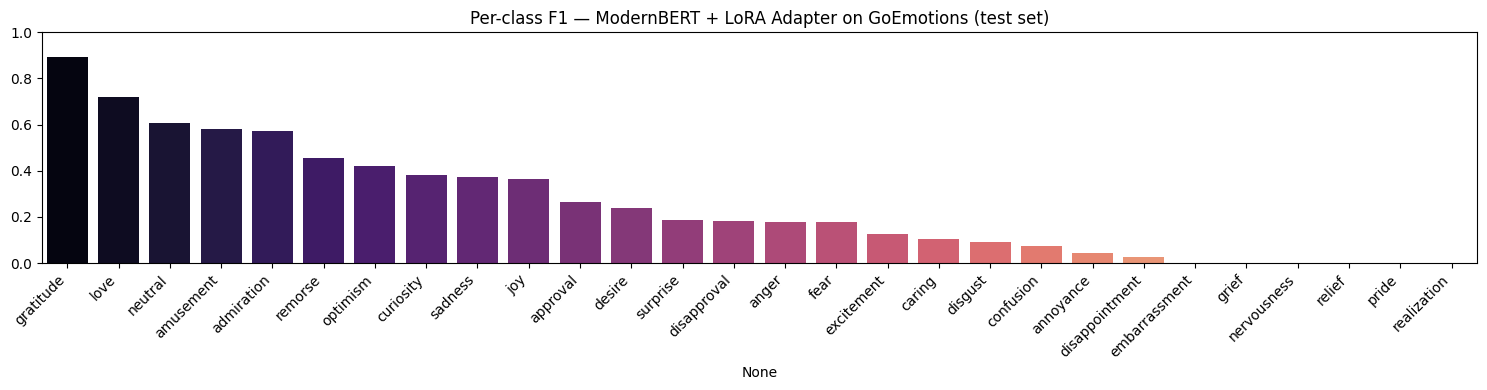

In [ ]:
# ── Per-class F1 bar chart ─────────────────────────────────────────────────
report = classification_report(
    test_labels, preds, target_names=emotion_labels,
    zero_division=0, output_dict=True
)
f1_series = pd.Series(
    {lbl: report[lbl]["f1-score"] for lbl in emotion_labels}
).sort_values(ascending=False)

plt.figure(figsize=(15, 4))
sns.barplot(x=f1_series.index, y=f1_series.values, palette="magma")
plt.xticks(rotation=45, ha="right")
plt.title("Per-class F1 — ModernBERT + LoRA Adapter on GoEmotions (test set)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [17]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}/")

Model saved to ./modernbert-goemotions-lora/
